# Weather ETL Pipeline
Extracts live weather data from the OpenWeather API for 10 global cities,
transforms it into a clean dataset, and loads it into CSV and SQLite.

**Tools:** Python, Requests, Pandas, SQLite
**Data source:** OpenWeather Current Weather API

In [12]:
from google.colab import userdata
print(userdata.get('OWM_API_KEY')[:6] + "...")

8c70b6...


## 1. Setup and API Connection
The API key is stored as a Colab secret, not in the notebook.
A single test call confirms the connection before running the full extraction.

In [13]:
import requests
from google.colab import userdata

API_KEY = userdata.get('OWM_API_KEY')

r = requests.get("https://api.openweathermap.org/data/2.5/weather",
                 params={"q": "Pretoria", "appid": API_KEY, "units": "metric"})

print(r.status_code)
print(r.json()["main"]["temp"], "°C")

200
27.67 °C


In [14]:
print(r.json())

{'coord': {'lon': 28.1878, 'lat': -25.7449}, 'weather': [{'id': 800, 'main': 'Clear', 'description': 'clear sky', 'icon': '01d'}], 'base': 'stations', 'main': {'temp': 27.67, 'feels_like': 26.63, 'temp_min': 26.4, 'temp_max': 28.28, 'pressure': 1022, 'humidity': 24, 'sea_level': 1022, 'grnd_level': 879}, 'visibility': 10000, 'wind': {'speed': 1.54, 'deg': 290}, 'clouds': {'all': 0}, 'dt': 1787143865, 'sys': {'type': 2, 'id': 2108577, 'country': 'ZA', 'sunrise': 1787113951, 'sunset': 1787154582}, 'timezone': 7200, 'id': 964137, 'name': 'Pretoria', 'cod': 200}


## 2. Extract
Ten cities across different climates, hemispheres and time zones.
Country codes are included to avoid ambiguous city name matches.

In [15]:
CITIES = [
    "Pretoria,ZA",
    "Cape Town,ZA",
    "Durban,ZA",
    "Nairobi,KE",
    "Cairo,EG",
    "London,GB",
    "Reykjavik,IS",
    "Dubai,AE",
    "Singapore,SG",
    "Sydney,AU",
]

In [16]:
import json

r = requests.get("https://api.openweathermap.org/data/2.5/weather",
                 params={"q": "Pretoria,ZA", "appid": API_KEY, "units": "metric"})

print(json.dumps(r.json(), indent=2))

{
  "coord": {
    "lon": 28.1878,
    "lat": -25.7449
  },
  "weather": [
    {
      "id": 800,
      "main": "Clear",
      "description": "clear sky",
      "icon": "01d"
    }
  ],
  "base": "stations",
  "main": {
    "temp": 28.1,
    "feels_like": 27.04,
    "temp_min": 27.54,
    "temp_max": 28.28,
    "pressure": 1022,
    "humidity": 27,
    "sea_level": 1022,
    "grnd_level": 879
  },
  "visibility": 10000,
  "wind": {
    "speed": 1.54,
    "deg": 290
  },
  "clouds": {
    "all": 0
  },
  "dt": 1787143458,
  "sys": {
    "type": 2,
    "id": 2108577,
    "country": "ZA",
    "sunrise": 1787113951,
    "sunset": 1787154582
  },
  "timezone": 7200,
  "id": 964137,
  "name": "Pretoria",
  "cod": 200
}


The extraction function returns None on failure rather than raising,
so one failed city does not stop the whole run.

In [17]:
import requests

def fetch_weather(city, api_key):
    """Fetch current weather for one city. Returns a dict, or None on failure."""
    url = "https://api.openweathermap.org/data/2.5/weather"
    params = {"q": city, "appid": api_key, "units": "metric"}

    try:
        r = requests.get(url, params=params, timeout=10)

        if r.status_code != 200:
            print(f"  {city}: failed ({r.status_code})")
            return None

        return r.json()

    except requests.exceptions.RequestException as e:
        print(f"  {city}: connection error - {e}")
        return None

## 3. Transform
The API returns nested JSON. This flattens each response into a single row,
renames fields to clear names, and includes units in the column names
(temp_c, humidity_pct) so the measurement is never ambiguous.

In [18]:
import time

raw_data = []

for city in CITIES:
    result = fetch_weather(city, API_KEY)
    if result:
        raw_data.append(result)
        print(f"  {city}: OK")
    time.sleep(1)

print(f"\nCollected {len(raw_data)} of {len(CITIES)} cities")

  Pretoria,ZA: OK
  Cape Town,ZA: OK
  Durban,ZA: OK
  Nairobi,KE: OK
  Cairo,EG: OK
  London,GB: OK
  Reykjavik,IS: OK
  Dubai,AE: OK
  Singapore,SG: OK
  Sydney,AU: OK

Collected 10 of 10 cities


In [19]:
from datetime import datetime, timezone

def parse_weather(data):
    """Flatten one API response into a single row."""
    return {
        "city":        data["name"],
        "country":     data["sys"]["country"],
        "temp_c":      data["main"]["temp"],
        "feels_like_c": data["main"]["feels_like"],
        "humidity_pct": data["main"]["humidity"],
        "pressure_hpa": data["main"]["pressure"],
        "condition":   data["weather"][0]["main"],
        "description": data["weather"][0]["description"],
        "wind_speed_ms": data["wind"]["speed"],
        "recorded_at": datetime.fromtimestamp(data["dt"], timezone.utc).replace(tzinfo=None),
    }

In [20]:
import pandas as pd

rows = []
for record in raw_data:
    rows.append(parse_weather(record))

df = pd.DataFrame(rows)
print(df.shape)
df.head()

(10, 10)


,city,country,temp_c,feels_like_c,humidity_pct,pressure_hpa,condition,description,wind_speed_ms,recorded_at
0,Pretoria,ZA,28.10,27.04,27,1022,Clear,clear sky,1.54,2026-08-19 12:44:18
1,Cape Town,ZA,18.87,18.43,62,1023,Clouds,broken clouds,5.14,2026-08-19 12:51:06
2,Durban,ZA,24.74,24.99,66,1018,Clear,clear sky,0.89,2026-08-19 12:51:07
3,Nairobi,KE,21.93,21.64,56,1016,Clouds,overcast clouds,2.06,2026-08-19 12:39:59
4,Cairo,EG,33.42,33.03,33,1010,Clear,clear sky,7.20,2026-08-19 12:48:02


Data quality checks: types, missing values and shape.

In [21]:
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum())
print("\nShape:", df.shape)

city                     object
country                  object
temp_c                  float64
feels_like_c            float64
humidity_pct              int64
pressure_hpa              int64
condition                object
description              object
wind_speed_ms           float64
recorded_at      datetime64[ns]
dtype: object

Missing values:
city             0
country          0
temp_c           0
feels_like_c     0
humidity_pct     0
pressure_hpa     0
condition        0
description      0
wind_speed_ms    0
recorded_at      0
dtype: int64

Shape: (10, 10)


## 4. Load
Saved to both CSV and SQLite. The database uses append mode, so each
pipeline run adds to the dataset rather than overwriting it.

In [22]:
df.to_csv("weather_data.csv", index=False)
print("Saved", len(df), "rows to weather_data.csv")


Saved 10 rows to weather_data.csv


In [23]:
import sqlite3

conn = sqlite3.connect("weather.db")
df.to_sql("weather", conn, if_exists="append", index=False)

check = pd.read_sql("SELECT COUNT(*) AS rows FROM weather", conn)
conn.close()

print("Rows in database:", check["rows"][0])

Rows in database: 10


## 5. Analysis

In [24]:
temps = df[["city", "country", "temp_c", "feels_like_c", "condition"]].sort_values("temp_c", ascending=False)
temps

print(f"Hottest: {df.loc[df['temp_c'].idxmax(), 'city']} at {df['temp_c'].max():.1f}°C")
print(f"Coldest: {df.loc[df['temp_c'].idxmin(), 'city']} at {df['temp_c'].min():.1f}°C")
print(f"Range:   {df['temp_c'].max() - df['temp_c'].min():.1f}°C")

Hottest: Dubai at 38.0°C
Coldest: Reykjavik at 11.8°C
Range:   26.1°C


In [25]:
# Highest humidity
print(f"Most humid:  {df.loc[df['humidity_pct'].idxmax(), 'city']} at {df['humidity_pct'].max()}%")
print(f"Least humid: {df.loc[df['humidity_pct'].idxmin(), 'city']} at {df['humidity_pct'].min()}%")

# Compare weather conditions
print("\nWeather conditions across cities:")
print(df["condition"].value_counts())

Most humid:  Reykjavik at 76%
Least humid: Pretoria at 27%

Weather conditions across cities:
condition
Clear     6
Clouds    4
Name: count, dtype: int64


In [26]:
print(f"Hottest: {df.loc[df['temp_c'].idxmax(), 'city']} at {df['temp_c'].max():.1f}°C")
print(f"Coldest: {df.loc[df['temp_c'].idxmin(), 'city']} at {df['temp_c'].min():.1f}°C")
print(f"Range:   {df['temp_c'].max() - df['temp_c'].min():.1f}°C")
print(f"Average: {df['temp_c'].mean():.1f}°C")

Hottest: Dubai at 38.0°C
Coldest: Reykjavik at 11.8°C
Range:   26.1°C
Average: 24.4°C


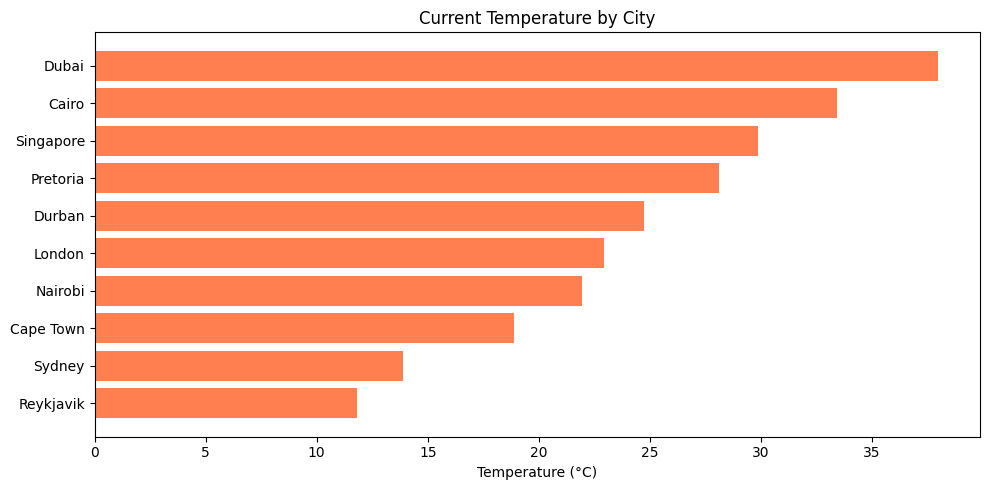

In [31]:
import matplotlib.pyplot as plt

plot_df = df.sort_values("temp_c")

plt.figure(figsize=(10, 5))
plt.barh(plot_df["city"], plot_df["temp_c"], color="coral")
plt.title("Current Temperature by City")
plt.xlabel("Temperature (°C)")
plt.tight_layout()
plt.show()

The chart compares the current temperature in all 10 cities, sorted from
coldest to hottest.

Dubai is the hottest at about 38°C and Reykjavik the coldest at about 12°C.

Dubai and Cairo are in northern
summer desert climates. Reykjavik sits close to the Arctic Circle. Sydney is
in southern winter. The three South African cities fall in the middle range.

In [27]:
%%writefile etl_pipeline.py
"""
Weather ETL Pipeline
Extracts current weather from the OpenWeather API, transforms it into a
clean table, and loads it into CSV and SQLite.
"""

import os
import time
import sqlite3
from datetime import datetime

import requests
import pandas as pd

API_KEY = os.environ.get("OWM_API_KEY")
BASE_URL = "https://api.openweathermap.org/data/2.5/weather"

CITIES = ["Pretoria,ZA", "Cape Town,ZA", "Durban,ZA", "Nairobi,KE", "Cairo,EG",
          "London,GB", "Reykjavik,IS", "Dubai,AE", "Singapore,SG", "Sydney,AU"]


def extract(city, api_key):
    """Fetch raw weather data for one city."""
    try:
        r = requests.get(BASE_URL,
                         params={"q": city, "appid": api_key, "units": "metric"},
                         timeout=10)
        if r.status_code != 200:
            print(f"  {city}: failed ({r.status_code})")
            return None
        return r.json()
    except requests.exceptions.RequestException as e:
        print(f"  {city}: connection error - {e}")
        return None


def transform(records):
    """Flatten raw API responses into a clean DataFrame."""
    rows = [{
        "city": d["name"],
        "country": d["sys"]["country"],
        "temp_c": d["main"]["temp"],
        "feels_like_c": d["main"]["feels_like"],
        "humidity_pct": d["main"]["humidity"],
        "pressure_hpa": d["main"]["pressure"],
        "condition": d["weather"][0]["main"],
        "description": d["weather"][0]["description"],
        "wind_speed_ms": d["wind"]["speed"],
        "recorded_at": datetime.utcfromtimestamp(d["dt"]),
    } for d in records]

    df = pd.DataFrame(rows)

    numeric = ["temp_c", "feels_like_c", "humidity_pct", "pressure_hpa", "wind_speed_ms"]
    for col in numeric:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["city"] = df["city"].str.strip().str.title()
    df["temp_diff_c"] = df["feels_like_c"] - df["temp_c"]
    df["collected_at"] = pd.Timestamp.now()

    return df.sort_values("temp_c", ascending=False).reset_index(drop=True)


def load(df, csv_path="data/weather_data.csv", db_path="data/weather.db"):
    """Save the clean data to CSV and SQLite."""
    os.makedirs("data", exist_ok=True)

    header = not os.path.exists(csv_path)
    df.to_csv(csv_path, mode="a", header=header, index=False)

    conn = sqlite3.connect(db_path)
    df.to_sql("weather", conn, if_exists="append", index=False)
    conn.close()

    print(f"Loaded {len(df)} rows to {csv_path} and {db_path}")


def main():
    if not API_KEY:
        raise SystemExit("OWM_API_KEY environment variable not set.")

    print("Extracting...")
    raw = []
    for city in CITIES:
        result = extract(city, API_KEY)
        if result:
            raw.append(result)
            print(f"  {city}: OK")
        time.sleep(1)

    if not raw:
        raise SystemExit("No data collected.")

    print(f"\nTransforming {len(raw)} records...")
    df = transform(raw)

    print("Loading...")
    load(df)
    print("\nPipeline complete.")


if __name__ == "__main__":
    main()

Writing etl_pipeline.py


In [28]:
%%writefile requirements.txt
requests>=2.31.0
pandas>=2.0.0

Writing requirements.txt


In [29]:
%%writefile .gitignore
# Secrets
.env
*.key

# Data outputs
data/*.db

# Python
__pycache__/
*.pyc
.ipynb_checkpoints/

Writing .gitignore


In [30]:
import os
from google.colab import userdata

os.environ["OWM_API_KEY"] = userdata.get("OWM_API_KEY")

!python etl_pipeline.py

Extracting...
  Pretoria,ZA: OK
  Cape Town,ZA: OK
  Durban,ZA: OK
  Nairobi,KE: OK
  Cairo,EG: OK
  London,GB: OK
  Reykjavik,IS: OK
  Dubai,AE: OK
  Singapore,SG: OK
  Sydney,AU: OK

Transforming 10 records...
/content/etl_pipeline.py:49: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  "recorded_at": datetime.utcfromtimestamp(d["dt"]),
Loading...
Loaded 10 rows to data/weather_data.csv and data/weather.db

Pipeline complete.


In [32]:
print(f"Hottest: {df.loc[df['temp_c'].idxmax(), 'city']} at {df['temp_c'].max():.1f}°C")
print(f"Coldest: {df.loc[df['temp_c'].idxmin(), 'city']} at {df['temp_c'].min():.1f}°C")
print(f"Most humid: {df.loc[df['humidity_pct'].idxmax(), 'city']} at {df['humidity_pct'].max()}%")
print(f"Least humid: {df.loc[df['humidity_pct'].idxmin(), 'city']} at {df['humidity_pct'].min()}%")
print(df["condition"].value_counts())

Hottest: Dubai at 38.0°C
Coldest: Reykjavik at 11.8°C
Most humid: Reykjavik at 76%
Least humid: Pretoria at 27%
condition
Clear     6
Clouds    4
Name: count, dtype: int64
